# Lesson 06: Execution quality and TCA (slippage, latency, markups, markouts)
**Level:** advanced

Transaction Cost Analysis (TCA) looks at execution from the **client's** side: what price did they ask for, what did
they get, how long did it take, and what happened next? This lesson covers four incidents:
* **S09**: B-book slippage that is **asymmetric** (clients get only the bad side)
* **S03 / S07**: latency decomposition (where are the milliseconds lost?)
* **S04**: a fat-finger **markup** that silently widened a group's spread
* **S11**: **toxic flow**: clients whose trades consistently win in the seconds after execution

In [1]:
import sys; sys.path.insert(0, "..")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from bridgelab import analysis as A, plotting as P
P.setup()
pd.set_option("display.width", 200, "display.max_columns", 30)

msgs = A.load_fix_messages()
quotes = A.lp_quotes(msgs)
orders, deals = A.load_platform()
cq = A.load_client_quotes()
sym, cfg, audit, clients = A.load_reference()
PIP, CONTRACT = sym.pip_size.to_dict(), sym.contract_size.to_dict()
PIP_VALUE_USD = {"EURUSD": 10.0, "GBPUSD": 10.0, "XAUUSD": 10.0}     # USD per pip per lot (pip x contract size)

f = orders[orders.filled_lots > 0].copy()
f["sign"] = np.where(f.side == "BUY", 1, -1)
f["slippage_pips"] = (f.requested_price - f.fill_price) * f.sign / f.symbol.map(PIP)     # + = better for the client
f["latency_ms"] = (f.client_recv_time - f.client_send_time).dt.total_seconds() * 1000
f[["order_id", "client_id", "book", "symbol", "side", "lots", "requested_price", "fill_price", "slippage_pips", "latency_ms"]].head()

,order_id,client_id,book,symbol,side,lots,requested_price,fill_price,slippage_pips,latency_ms
0,700001,C1007,B,EURUSD,SELL,4.90,1.16252,1.16252,-0.0,95.0
1,700002,C1029,B,XAUUSD,BUY,0.43,4086.09000,4086.09000,0.0,87.0
2,700003,C1025,B,XAUUSD,SELL,4.22,4085.53000,4085.53000,-0.0,98.0
3,700004,C1041,A,XAUUSD,SELL,9.40,4085.76000,4085.72000,-0.4,289.0
4,700005,C1040,A,EURUSD,SELL,2.62,1.16244,1.16244,-0.0,107.0


## 1. Slippage by book: is it symmetric? (S09)
Prices move between the click and the execution. In a fair execution model clients get **both** negative
slippage (price moved against them) **and** positive slippage (price moved for them). Regulators (FCA, ESMA, CySEC)
treat "negative only" slippage as unfair treatment of clients.

In [2]:
def sym_table(df):
    return pd.Series({"fills": len(df), "positive %": 100 * (df.slippage_pips > 0.05).mean(),
                      "zero %": 100 * (df.slippage_pips.abs() <= 0.05).mean(), "negative %": 100 * (df.slippage_pips < -0.05).mean(),
                      "avg slippage pips": df.slippage_pips.mean()})
f.groupby("book").apply(sym_table, include_groups=False).round(2)

,fills,positive %,zero %,negative %,avg slippage pips
book,,,,,
A,648.0,4.01,70.68,25.31,-0.76
B,864.0,0.00,96.41,3.59,-0.01


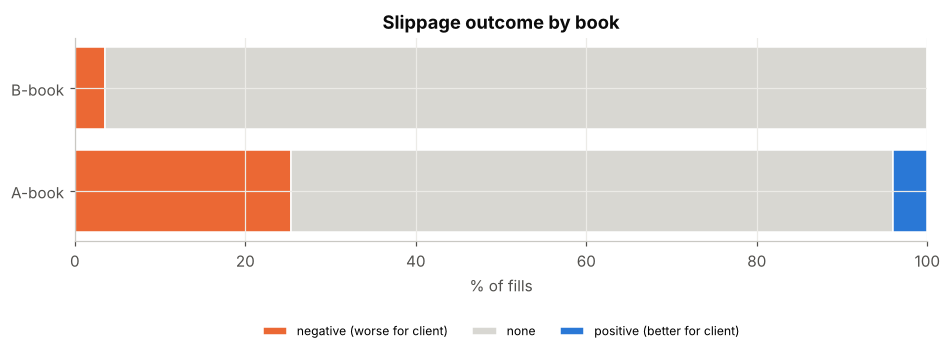

In [3]:
shares = f.groupby("book").slippage_pips.apply(lambda s: pd.Series({
    "negative (worse for client)": (s < -0.05).mean(), "none": (s.abs() <= 0.05).mean(),
    "positive (better for client)": (s > 0.05).mean()})).unstack() * 100
fig, ax = plt.subplots(figsize=(10, 2.4))
left = np.zeros(len(shares))
for col, color in zip(shares.columns, [P.SERIES[1], "#d8d7d2", P.SERIES[0]]):
    ax.barh([f"{b}-book" for b in shares.index], shares[col], left=left, color=color, label=col, edgecolor="white")
    left += shares[col].values
ax.set_xlim(0, 100); ax.set_xlabel("% of fills"); ax.set_title("Slippage outcome by book")
ax.legend(ncol=3, fontsize=8, loc="upper center", bbox_to_anchor=(0.5, -0.35)); plt.show()

* **A-book** slippage is **two-sided**: both positive and negative values occur. It leans negative because of
  last-look rejects, re-routes and gold sweeps through several LPs (Lesson 05). Those are routing problems, not an
  execution rule.
* **B-book** slippage is **never positive**: when the market moved for the client, the platform kept the requested
  price; when it moved against them, the client got the worse price. The config says it outright:
  `b_book_execution.slippage_mode = client_adverse_only`.

**How much did clients lose from the withheld positive slippage?** For B-book fills, compare the fill with the
market price the client could have had at execution time (the group's quote at fill time).

In [4]:
b = f[f.book == "B"].copy()
b["market_at_fill"] = np.nan
for (s, g), idx in b.groupby(["symbol", "group"]).groups.items():
    qs = cq[(cq.symbol == s) & (cq.group == g)].set_index("time")
    side_px = np.where(b.loc[idx, "side"] == "BUY", A.value_at(qs.ask, b.loc[idx, "server_fill_time"]),
                       A.value_at(qs.bid, b.loc[idx, "server_fill_time"]))
    b.loc[idx, "market_at_fill"] = side_px
b["withheld_pips"] = ((b.fill_price - b.market_at_fill) * b.sign / b.symbol.map(PIP)).clip(lower=0)
b["withheld_usd"] = b.withheld_pips * b.lots * b.symbol.map(PIP_VALUE_USD)
b["passed_usd"] = (b.slippage_pips.clip(upper=0) * b.lots * b.symbol.map(PIP_VALUE_USD))
print(f"B-book fills where positive slippage was withheld: {(b.withheld_pips > 0.05).sum()} of {len(b)}")
print(f"Positive slippage withheld from clients: ${b.withheld_usd.sum():,.0f} | negative slippage passed on: ${-b.passed_usd.sum():,.0f}")
b.groupby("symbol").withheld_usd.sum().round(0)

B-book fills where positive slippage was withheld: 32 of 864
Positive slippage withheld from clients: $198 | negative slippage passed on: $182


symbol
EURUSD     19.0
GBPUSD     34.0
XAUUSD    145.0
Name: withheld_usd, dtype: float64

The amounts are small in a 2-hour quiet session, but the bias is **systematic**. Scaled to a year of flow it
becomes a material sum and a conduct issue. **Fix:** switch B-book execution to **symmetric** slippage (fill at the market price at execution, whichever way it
moved), or symmetric tolerance bands. Then document it in the order execution policy.

## 2. Latency decomposition (A-book)
Every A-book order carries a timestamp at each hop, so we can see where the time goes.

In [5]:
a = f[f.book == "A"].copy()
hops = pd.DataFrame({
    "client→server": (a.server_recv_time - a.client_send_time),
    "server→bridge": (a.bridge_recv_time - a.server_recv_time),
    "bridge processing": (a.lp_send_time - a.bridge_recv_time),
    "LP round trip(s)": (a.lp_response_time - a.lp_send_time),
    "bridge→server": (a.server_fill_time - a.lp_response_time),
    "server→client": (a.client_recv_time - a.server_fill_time),
}).apply(lambda s: s.dt.total_seconds() * 1000)
hops.index = a.lp_send_time
hops.describe(percentiles=[.5, .95, .99]).T[["50%", "95%", "99%", "max"]].round(1)

,50%,95%,99%,max
client→server,41.0,67.0,69.5,70.0
server→bridge,2.0,3.0,3.0,3.0
bridge processing,1.0,2.0,138.8,245.0
LP round trip(s),109.5,208.0,549.1,619.0
bridge→server,2.0,3.0,3.0,3.0
server→client,43.0,67.0,69.0,70.0


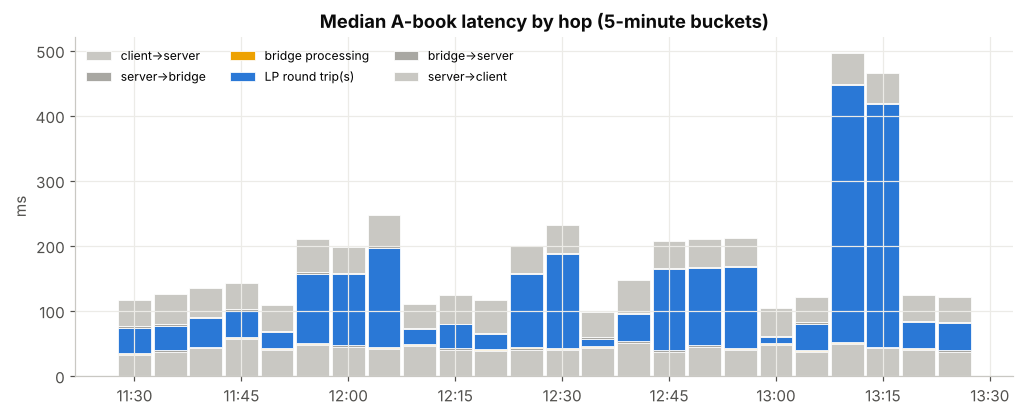

In [6]:
per5 = hops.resample("5min").median()
fig, ax = plt.subplots()
bottom = np.zeros(len(per5))
colors = {"client→server": "#c9c8c3", "server→bridge": "#a8a7a2", "bridge processing": P.SERIES[3],
          "LP round trip(s)": P.SERIES[0], "bridge→server": "#a8a7a2", "server→client": "#c9c8c3"}
for c in per5.columns:
    ax.bar(per5.index, per5[c], bottom=bottom, width=0.0032, color=colors[c], label=c, edgecolor="white", linewidth=0.5)
    bottom += per5[c].fillna(0).values
ax.set_title("Median A-book latency by hop (5-minute buckets)"); ax.set_ylabel("ms")
P.time_axis(ax); ax.legend(fontsize=8, ncol=3); plt.show()

In [7]:
def window(t0, t1):
    return hops[(hops.index >= t0) & (hops.index < t1)].median()
pd.DataFrame({"normal (11:30-12:25)": window("2025-10-15 11:30", "2025-10-15 12:25"),
              "news 12:30:00-12:30:30": window("2025-10-15 12:30:00", "2025-10-15 12:30:30"),
              "13:10-13:20": window("2025-10-15 13:10", "2025-10-15 13:20")}).round(1)

,normal (11:30-12:25),news 12:30:00-12:30:30,13:10-13:20
client→server,41.0,40.0,44.0
server→bridge,2.0,2.0,2.0
bridge processing,1.0,160.0,1.0
LP round trip(s),43.0,143.0,386.5
bridge→server,2.0,1.0,2.0
server→client,43.0,48.0,47.0


Two different bottlenecks:
* **12:30 news:** the **bridge processing** time jumps from ~1 ms to well over 100 ms. The bridge's queue is backing
  up while it handles 4x the market data plus a burst of orders. That's a bridge **capacity** problem.
* **13:10–13:20:** bridge processing is normal, but the **LP round trip** explodes, and only for orders routed to
  LP_A (Lesson 05). That's an **LP-side** problem.

Without per-hop timestamps, both would look like "the broker is slow". With them, you know whom to call.

## 3. Does latency cost money? It depends on who carries the risk
While an order is in flight, the market keeps moving. Measure the **market move during the LP round trip**, from the
client's side, for LP_A orders in normal times vs the 13:10–13:20 slowdown.

In [8]:
mid = {s: A.mid_series(quotes, s) for s in sym.index}
la = a[a.lp == "LP_A"].copy()
la["rtt_ms"] = (la.lp_response_time - la.lp_send_time).dt.total_seconds() * 1000
la["move_pips"] = np.nan
for s in sym.index:
    m = la.symbol == s
    la.loc[m, "move_pips"] = ((A.value_at(mid[s], la.loc[m, "lp_response_time"]) - A.value_at(mid[s], la.loc[m, "lp_send_time"]))
                              * la.loc[m, "sign"] / PIP[s])
la["period"] = np.where(la.lp_send_time.between("2025-10-15 13:10", "2025-10-15 13:20"), "13:10-13:20 (slow)", "normal")
la.groupby("period").agg(fills=("order_id", "size"), median_rtt_ms=("rtt_ms", "median"),
                         avg_abs_move_pips=("move_pips", lambda s: s.abs().mean())).round(3)

,fills,median_rtt_ms,avg_abs_move_pips
period,,,
13:10-13:20 (slow),25,423.0,0.050
normal,293,8.0,0.018


During the slowdown the market moved roughly 3x further while orders were in flight, but LP_A is a **firm** LP: it filled at
the quoted price anyway, so **LP_A absorbed the move** and clients only waited longer. With a last-look LP, the same
delay would have turned into more rejects and re-routes (worse prices for clients). Either way, persistent latency
gets priced in eventually: LPs widen spreads for flow that reaches them late.

## 4. Markups: are clients getting the spread we think? (S04)
Client spread = raw aggregated spread + 2 × markup. Check the **STD − RAW** spread difference per symbol over time.
It should be flat at 2 × the configured markup.

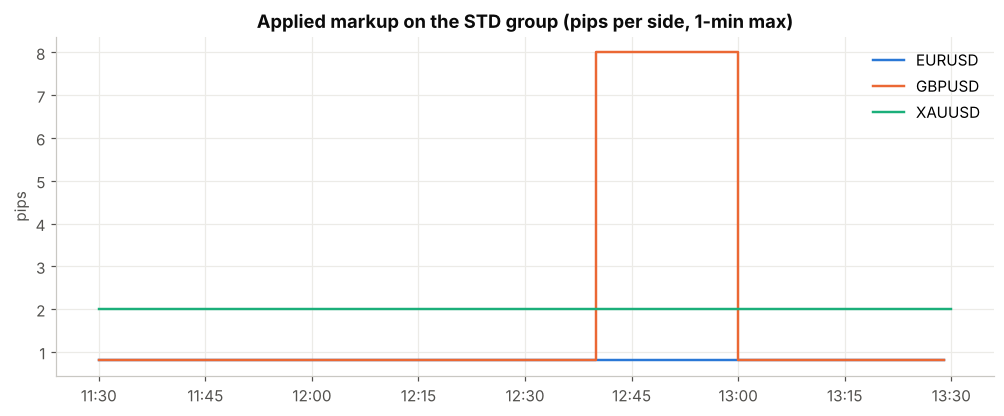

Configured STD markups: {'EURUSD': 0.8, 'GBPUSD': 0.8, 'XAUUSD': 2.0}


In [9]:
w = cq.assign(spread=cq.ask - cq.bid).pivot_table(index=["time", "symbol"], columns="group", values="spread").reset_index()
w["markup_pips_per_side"] = (w.STD - w.RAW) / 2 / w.symbol.map(PIP)
fig, ax = plt.subplots()
for i, s in enumerate(sym.index):
    g = w[w.symbol == s].set_index("time").markup_pips_per_side.resample("1min").max()
    ax.plot(g.index, g.values, color=P.SERIES[i], label=s, drawstyle="steps-post")
ax.set_title("Applied markup on the STD group (pips per side, 1-min max)"); ax.set_ylabel("pips")
P.time_axis(ax); ax.legend(); plt.show()
print("Configured STD markups:", cfg["markups_pips_per_side"]["STD"])

In [10]:
bad = w[(w.symbol == "GBPUSD") & (w.markup_pips_per_side > 2)]
print(f"GBPUSD STD markup at {bad.markup_pips_per_side.median():.1f} pips from {bad.time.min()} to {bad.time.max()}")
audit

GBPUSD STD markup at 8.0 pips from 2025-10-15 12:40:00.440000 to 2025-10-15 12:59:59.481000


,time,user,object,change,ticket
0,2025-10-14 16:20:05.000,admin,LP_C session,lp_quantity_multiplier XAUUSD set to 1,CHG-2291 (new LP onboarding)
1,2025-10-15 12:39:56.800,dealer2,Group STD / GBPUSD,markup 0.8 -> 8.0 pips,none
2,2025-10-15 13:00:00.400,dealer1,Group STD / GBPUSD,markup 8.0 -> 0.8 pips,INC-5521 client complaints


In [11]:
hit = f[(f.symbol == "GBPUSD") & (f.group == "STD") & f.server_fill_time.between(bad.time.min(), bad.time.max())].copy()
hit["overcharge_usd"] = (bad.markup_pips_per_side.median() - cfg["markups_pips_per_side"]["STD"]["GBPUSD"]) * hit.lots * PIP_VALUE_USD["GBPUSD"]
print(f"STD GBPUSD trades executed with the wrong markup: {len(hit)} by {hit.client_id.nunique()} clients, "
      f"overcharge ${hit.overcharge_usd.sum():,.0f}")
hit[["order_id", "client_id", "side", "lots", "server_fill_time", "fill_price", "overcharge_usd"]].round({"overcharge_usd": 2})

STD GBPUSD trades executed with the wrong markup: 26 by 21 clients, overcharge $3,738


,order_id,client_id,side,lots,server_fill_time,fill_price,overcharge_usd
922,700923,C1008,SELL,0.44,2025-10-15 12:41:44.033,1.33715,31.68
929,700930,C1033,BUY,0.62,2025-10-15 12:42:12.296,1.33884,44.64
932,700933,C1040,BUY,0.78,2025-10-15 12:42:21.010,1.33884,56.16
934,700935,C1003,SELL,1.73,2025-10-15 12:42:24.158,1.33719,124.56
941,700942,C1060,SELL,0.65,2025-10-15 12:43:21.664,1.33724,46.80
942,700943,C1021,SELL,8.91,2025-10-15 12:43:30.373,1.33727,641.52
945,700946,C1043,SELL,0.11,2025-10-15 12:43:53.739,1.33722,7.92
956,700957,C1046,SELL,0.49,2025-10-15 12:44:48.848,1.33723,35.28
975,700976,C1024,BUY,5.04,2025-10-15 12:45:47.765,1.33879,362.88
976,700977,C1008,SELL,0.34,2025-10-15 12:45:49.323,1.33714,24.48


**S04 found:** at 12:39:56 `dealer2` changed the GBPUSD markup on the STD group from 0.8 to **8.0** pips (a typo,
no ticket). Clients saw a ~17-pip spread for 20 minutes. It was reverted at 13:00 only after complaints. Affected
clients should be **refunded** (the table above is the remediation list).

**Controls:** four-eyes approval for markup changes, hard limits per symbol (e.g. max 3 pips), and an alert when a
group's spread deviates from raw + configured markup.

## 5. Markouts: who is trading on information? (S11)
A **markout** measures how the mid moved after a trade, from the client's side:
`markout(h) = (mid(t+h) − mid(t)) × side`, in pips. For random retail flow it averages ~0 (minus spread).
Consistently positive markouts mean the client is **informed or latency-arbitraging**, i.e. **toxic** for whoever
holds the risk.

In [12]:
horizons = {"100ms": 0.1, "1s": 1, "5s": 5, "30s": 30, "60s": 60}
f["mid_0"] = np.nan
for s in sym.index:
    m = f.symbol == s
    f.loc[m, "mid_0"] = A.value_at(mid[s], f.loc[m, "server_fill_time"])
for name, sec in horizons.items():
    col = f"mo_{name}"
    f[col] = np.nan
    for s in sym.index:
        m = f.symbol == s
        f.loc[m, col] = (A.value_at(mid[s], f.loc[m, "server_fill_time"] + pd.Timedelta(seconds=sec)) - f.loc[m, "mid_0"]) \
                        * f.loc[m, "sign"] / PIP[s]
mo_cols = [f"mo_{h}" for h in horizons]
by_client = f.groupby("client_id").agg(fills=("order_id", "size"), lots=("lots", "sum"),
                                       **{c: (c, "mean") for c in mo_cols})
by_client = by_client[by_client.fills >= 10].sort_values("mo_5s", ascending=False)
by_client.head(8).round(2)

,fills,lots,mo_100ms,mo_1s,mo_5s,mo_30s,mo_60s
client_id,,,,,,,
C1023,83,478.70,-0.01,0.13,1.33,3.16,4.38
C1007,60,361.90,0.02,0.17,0.65,3.76,5.03
C1041,75,442.90,0.01,0.16,0.61,2.40,3.71
C1051,20,31.47,0.00,0.15,0.35,0.44,1.70
C1019,28,48.21,0.02,0.07,0.33,0.88,1.03
C1014,34,55.90,0.01,-0.04,0.30,-0.21,-0.61
C1016,24,42.75,0.03,0.04,0.27,0.48,-0.04
C1037,19,28.13,0.01,0.04,0.23,0.27,0.63


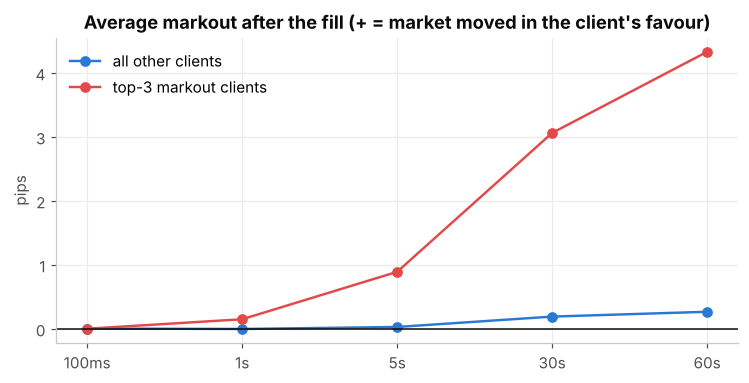

In [13]:
f["flow"] = np.where(f.client_id.isin(by_client.index[:3]), "top-3 markout clients", "all other clients")
curve = f.groupby("flow")[mo_cols].mean().T
curve.index = list(horizons)
fig, ax = plt.subplots(figsize=(8, 3.6))
for c in curve.columns:
    ax.plot(curve.index, curve[c], marker="o", color=P.ALERT if c.startswith("top") else P.SERIES[0], label=c)
ax.axhline(0, color=P.INK, lw=1)
ax.set_title("Average markout after the fill (+ = market moved in the client's favour)")
ax.set_ylabel("pips"); ax.legend(); plt.show()

In [14]:
tox = by_client.index[:3]
pnl = f[f.client_id.isin(tox)].groupby(["client_id", "book"]).agg(fills=("order_id", "size"),
                                                                   avg_markout_5s=("mo_5s", "mean")).round(2)
pnl["client_type"] = "latency arbitrage / informed"
pnl

,,fills,avg_markout_5s,client_type
client_id,book,,,
C1007,B,60,0.65,latency arbitrage / informed
C1023,B,83,1.33,latency arbitrage / informed
C1041,A,75,0.61,latency arbitrage / informed


**S11 found:** three clients (C1007, C1023, C1041) gain about **1 pip within 5 seconds** and **2–5 pips within
30–60 seconds** of their trades, on average across dozens of fills.
Normal clients' markouts hover around zero. These are the same accounts that hit the bad tick (S01) and the stale
gold feed (S02) in Lesson 04.

**What to do:**
* B-book toxic clients (C1007, C1023): move them to **A-book**, so their flow goes to LPs and the broker stops
  paying for their edge. Review their trades during S01/S02 under the manifest-error clause.
* A-book toxic clients (C1041): LPs see this flow too. Expect LP complaints, wider spreads or rejects. Options: a
  minimum holding time, a dedicated toxic-flow LP stream, or offboarding.
* Monitor markouts by client **and by IB** every day. Toxic flow often arrives in clusters from the same introducer.

## 6. Execution quality summary (best-execution style report)

In [15]:
rep = f.groupby(["symbol", "book"]).agg(fills=("order_id", "size"),
                                        avg_slippage_pips=("slippage_pips", "mean"),
                                        positive_slip_pct=("slippage_pips", lambda s: 100 * (s > 0.05).mean()),
                                        negative_slip_pct=("slippage_pips", lambda s: 100 * (s < -0.05).mean()),
                                        median_latency_ms=("latency_ms", "median"),
                                        p95_latency_ms=("latency_ms", lambda s: s.quantile(.95)))
rej = orders.groupby(["symbol", "book"]).apply(lambda g: 100 * (g.status == "REJECTED").mean(), include_groups=False).rename("reject_pct")
rep.join(rej).round(2)

fills  avg_slippage_pips  positive_slip_pct  negative_slip_pct  median_latency_ms  p95_latency_ms  reject_pct
symbol book                                                                                                               
EURUSD A       303              -0.18               2.64              13.53              146.0          284.00        0.00
       B       363              -0.00               0.00               3.31               88.0          120.90        0.00
GBPUSD A       105              -0.01               6.67              13.33              127.0          311.00        0.00
       B       144              -0.00               0.00               2.78               87.0          124.85        0.00
XAUUSD A       240              -1.83               4.58              45.42              221.0          498.15        1.23
       B       357              -0.02               0.00               4.20               87.0          123.20        0.00

**Next:** Lesson 07, reconciliation between the platform, the bridge and the LPs.